# Step 2: The baseline cavity

Where and how fast does the ice shelf melt in the baseline setup, and how does the water under the ice move? In this notebook I look at the geometry as the model sees it, the melt rate, temperature and salinity under the ice, the circulation, and how the melt rate changes over 5 years. I also look for the "ice pump": melting at depth, fresh meltwater rising along the ice base, and refreezing higher up.

The baseline is the original `isomip` setup with the three-equation melt model (`useISOMIPTD = .FALSE.`) and constant transfer coefficients, run for 5 model years (`experiments/baseline/input/`).

I load the libraries and the shared functions from `src/isomip_tools.py`, and set the paths.

In [1]:
%matplotlib inline

import os
import sys
import glob

import numpy as np
import matplotlib.pyplot as plt
from MITgcmutils import rdmds

sys.path.append("../src")   # isomip_tools.py lives in the project's src/ folder
from isomip_tools import (read_grid, output_iterations, read_field, melt_rate, area_mean, melt_series,
                          freezing_point, pressure_dbar, RHO_ICE, SECONDS_PER_YEAR, STEPS_PER_YEAR, DELTA_T)

RUN = os.path.expanduser("~/mitgcm_runs/isomip/baseline")
INPUT = os.path.expanduser("~/mitgcm_runs/isomip/source_copy/input")
SECTION_COLUMN = 25          # longitude index for the sections along the cavity (the setup is the same at every longitude)
FIG_DIR = "../figures"
DATA_DIR = "../data"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

I check that the run ended normally and that every output value is a finite number (the lesson from project 15: 'ended normally' alone is not enough).

In [2]:
text = open(os.path.join(RUN, "output.txt")).read()
print("ended normally:", "Execution ended Normally" in text, "| 'NaN' in log:", "NaN" in text)
bad = 0
checked = 0
for prefix in ["shelfice_monthly", "state_yearly"]:
    for it in output_iterations(RUN, prefix):
        checked += 1
        if not np.all(np.isfinite(rdmds(os.path.join(RUN, prefix), it))):   # rdmds reads the precision from the .meta file
            bad += 1
print(f"diagnostic output files with non-finite values: {bad} of {checked}")
grid = read_grid(RUN, INPUT)
lat = grid["yc"][:, 0]
lon = grid["xc"][0, :]
print(f"wet columns: {grid['wet'].sum()} | ocean volume {grid['volume']:.4e} m^3 | ice-covered area {np.sum(grid['rac'] * grid['wet']):.4e} m^2")

ended normally: True | 'NaN' in log: False
diagnostic output files with non-finite values: 0 of 65
wet columns: 4851 | ocean volume 2.9242e+14 m^3 | ice-covered area 4.6650e+11 m^2


## Geometry

Maps of the ice draft (depth of the ice base) and of the seafloor depth. The ice draft changes only from south to north, so the map shows bands.

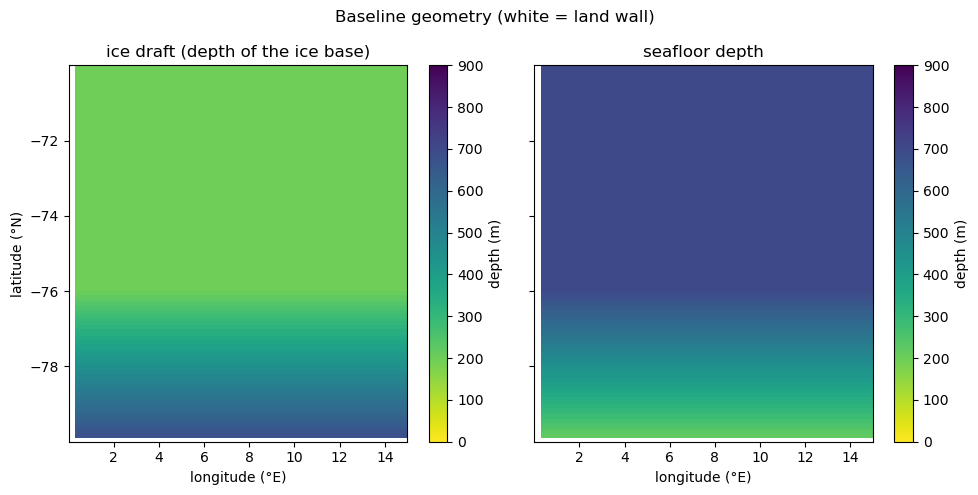

In [3]:
lat_edges = np.concatenate([lat - 0.05, [lat[-1] + 0.05]])
lon_edges = np.concatenate([lon - 0.15, [lon[-1] + 0.15]])
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
draft = np.where(grid["wet"], -grid["ice_draft"], np.nan)
seafloor = np.where(grid["wet"], grid["depth"], np.nan)
for ax, field, title in [(axes[0], draft, "ice draft (depth of the ice base)"), (axes[1], seafloor, "seafloor depth")]:
    mesh = ax.pcolormesh(lon_edges, lat_edges, field, cmap="viridis_r", vmin=0, vmax=900)
    fig.colorbar(mesh, ax=ax, label="depth (m)")
    ax.set_xlabel("longitude (°E)")
    ax.set_title(title)
axes[0].set_ylabel("latitude (°N)")
fig.suptitle("Baseline geometry (white = land wall)")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "02_geometry_maps.png"), dpi=150)
plt.show()

The cross-section shows the geometry as the model sees it: each grid cell is coloured by how open it is (`hFacC`, from 0 = solid to 1 = fully water). The smooth ice base becomes a staircase of full and partly open cells. The line is the true ice base from the input file.

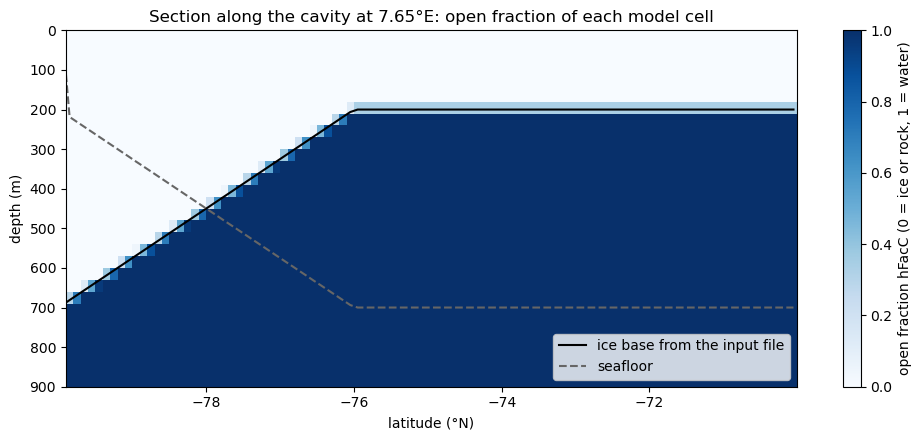

partly open cells: 4851 of 100597 wet cells


In [4]:
i = SECTION_COLUMN
depth_faces = -grid["rf"]
fig, ax = plt.subplots(figsize=(10, 4.5))
mesh = ax.pcolormesh(lat_edges, depth_faces, grid["hfacc"][:, :, i], cmap="Blues", vmin=0, vmax=1)
ax.plot(lat, -grid["ice_draft"][:, i], color="k", lw=1.5, label="ice base from the input file")
ax.plot(lat, grid["depth"][:, i], color="0.4", lw=1.5, ls="--", label="seafloor")
ax.set_ylim(900, 0)
ax.set_xlim(lat_edges[1], lat_edges[-1])
ax.set_xlabel("latitude (°N)")
ax.set_ylabel("depth (m)")
ax.set_title(f"Section along the cavity at {lon[i]:.2f}°E: open fraction of each model cell")
fig.colorbar(mesh, ax=ax, label="open fraction hFacC (0 = ice or rock, 1 = water)")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "02_geometry_section_cells.png"), dpi=150)
plt.show()
partial = np.sum((grid["hfacc"] > 0) & (grid["hfacc"] < 1))
print(f"partly open cells: {partial} of {np.sum(grid['hfacc'] > 0)} wet cells")

## Melt rate over time

The model gives the melt as a fresh-water flux `SHIfwFlx` in kg/m^2/s, positive upward, so melting is negative. To get metres of ice per year I divide by the ice density (917 kg/m^3), which gives metres of ice per second, and multiply by the seconds in a 365-day year (31 536 000 s). The minus sign makes melting positive and refreezing negative. Example: -1e-5 kg/m^2/s becomes 1e-5 / 917 x 31 536 000 = 0.344 m of ice per year.

In [5]:
print(f"example: SHIfwFlx = -1e-5 kg/m^2/s -> {melt_rate(-1e-5):.3f} m of ice per year")
days, melt = melt_series([RUN], grid)
years = days / 365.0
print(f"{len(melt)} monthly (30-day) means over {years[-1]:.2f} model years")
for target in [1 / 12, 0.5, 1, 2, 3, 4, years[-1]]:
    n = np.argmin(np.abs(years - target))
    print(f"   after {years[n]:5.2f} years: area-mean melt {melt[n]:.4f} m/yr")

example: SHIfwFlx = -1e-5 kg/m^2/s -> 0.344 m of ice per year
60 monthly (30-day) means over 4.93 model years
   after  0.08 years: area-mean melt 0.9198 m/yr
   after  0.49 years: area-mean melt 0.1205 m/yr
   after  0.99 years: area-mean melt 0.0843 m/yr
   after  1.97 years: area-mean melt 0.0591 m/yr
   after  2.96 years: area-mean melt 0.0472 m/yr
   after  4.03 years: area-mean melt 0.0404 m/yr
   after  4.93 years: area-mean melt 0.0369 m/yr


Is it steady? I compare the mean melt rate of the last 12 months with the 12 months before.

mean of the last 12 months: 0.0386 m/yr | the 12 months before: 0.0431 m/yr | change -0.0045 m/yr (-10.5%)


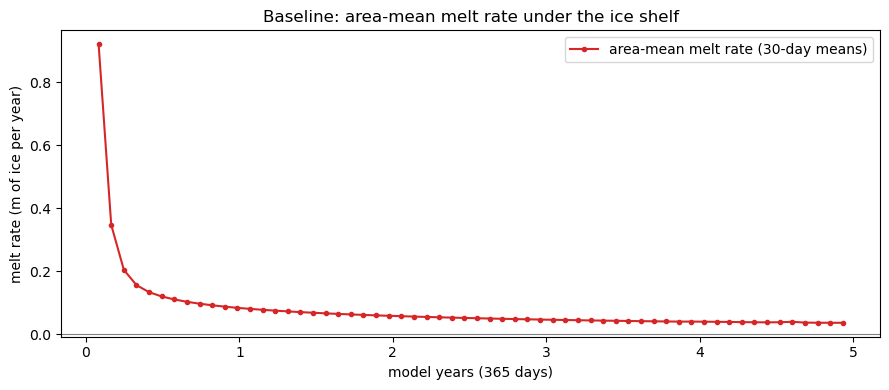

In [6]:
last = melt[-12:].mean()
before = melt[-24:-12].mean()
print(f"mean of the last 12 months: {last:.4f} m/yr | the 12 months before: {before:.4f} m/yr | "
      f"change {last - before:+.4f} m/yr ({100 * (last - before) / before:+.1f}%)")
np.savetxt(os.path.join(DATA_DIR, "melt_series_baseline.csv"), np.column_stack([days, melt]),
           delimiter=",", header="model_day,area_mean_melt_m_per_yr", comments="", fmt="%.4f")
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(years, melt, "o-", ms=3, color="tab:red", label="area-mean melt rate (30-day means)")
ax.axhline(0, color="0.5", lw=0.8)
ax.set_xlabel("model years (365 days)")
ax.set_ylabel("melt rate (m of ice per year)")
ax.set_title("Baseline: area-mean melt rate under the ice shelf")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "02_melt_timeseries.png"), dpi=150)
plt.show()

## Where the ice melts and where water refreezes

I average the monthly melt maps over the last model year. Red is melting, blue is refreezing (negative melt).

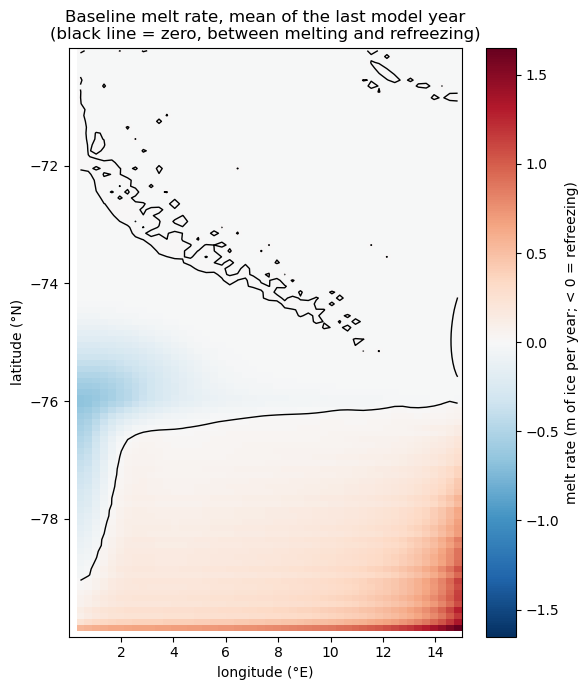

area-mean melt 0.0386 m/yr | largest melt 1.652 m/yr | strongest refreezing -0.668 m/yr | area refreezing 68.0%


In [7]:
its = output_iterations(RUN, "shelfice_monthly")[-12:]
melt_map = np.zeros(grid["wet"].shape)
for it in its:
    melt_map += melt_rate(read_field(RUN, "shelfice_monthly", "SHIfwFlx", it)) / len(its)
melt_map = np.where(grid["wet"], melt_map, np.nan)
limit = np.nanmax(np.abs(melt_map))
fig, ax = plt.subplots(figsize=(6, 7))
mesh = ax.pcolormesh(lon_edges, lat_edges, melt_map, cmap="RdBu_r", vmin=-limit, vmax=limit)
ax.contour(lon, lat, melt_map, levels=[0], colors="k", linewidths=1)
fig.colorbar(mesh, ax=ax, label="melt rate (m of ice per year; < 0 = refreezing)")
ax.set_xlabel("longitude (°E)")
ax.set_ylabel("latitude (°N)")
ax.set_title("Baseline melt rate, mean of the last model year\n(black line = zero, between melting and refreezing)")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "02_melt_map.png"), dpi=150)
plt.show()
w = grid["rac"] * grid["wet"]
print(f"area-mean melt {np.nansum(melt_map * w) / w.sum():.4f} m/yr | largest melt {np.nanmax(melt_map):.3f} m/yr | "
      f"strongest refreezing {np.nanmin(melt_map):.3f} m/yr | area refreezing {100 * np.sum(w * (melt_map < 0)) / w.sum():.1f}%")

Melt against the depth of the ice base, averaged across longitude: this is the ice pump in one line.

/var/folders/kt/tr31888s76x69sx243yv4p9r0000gn/T/ipykernel_21486/2387174404.py:1: RuntimeWarning: Mean of empty slice
  zonal_melt = np.nanmean(melt_map, axis=1)


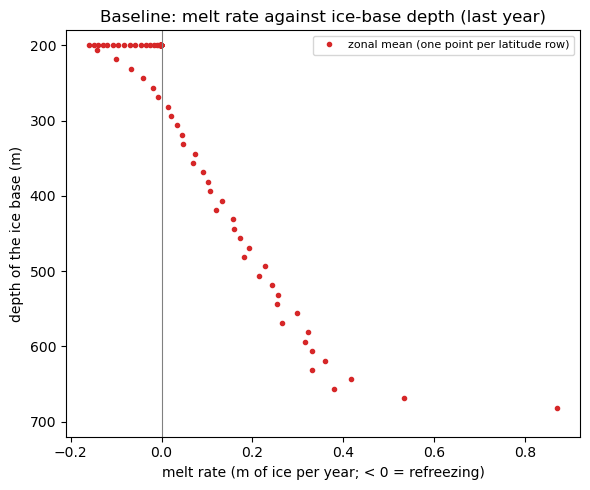

ice base near 681 m (latitude -79.85): melt +0.8699 m/yr
ice base near 594 m (latitude -79.15): melt +0.3161 m/yr
ice base near 494 m (latitude -78.35): melt +0.2281 m/yr
ice base near 394 m (latitude -77.55): melt +0.1054 m/yr
ice base near 294 m (latitude -76.75): melt +0.0203 m/yr
ice base near 200 m (latitude -75.95): melt -0.1594 m/yr


In [8]:
zonal_melt = np.nanmean(melt_map, axis=1)
zonal_draft = -grid["ice_draft"][:, 1]
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(zonal_melt[1:], zonal_draft[1:], "o", ms=3, color="tab:red", label="zonal mean (one point per latitude row)")
ax.axvline(0, color="0.5", lw=0.8)
ax.set_ylim(720, 180)
ax.set_xlabel("melt rate (m of ice per year; < 0 = refreezing)")
ax.set_ylabel("depth of the ice base (m)")
ax.set_title("Baseline: melt rate against ice-base depth (last year)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "02_melt_vs_draft.png"), dpi=150)
plt.show()
for d in [690, 600, 500, 400, 300, 200]:
    n = np.argmin(np.abs(zonal_draft[1:] - d)) + 1
    print(f"ice base near {zonal_draft[n]:.0f} m (latitude {lat[n]:.2f}): melt {zonal_melt[n]:+.4f} m/yr")

## Temperature and salinity under the ice

Sections along the cavity from the yearly mean of the last year. I also show the 'thermal driving': temperature minus the local freezing point, using the same freezing formula as the three-equation model. Where it is positive the water can melt ice; where it is negative it is supercooled and can freeze.

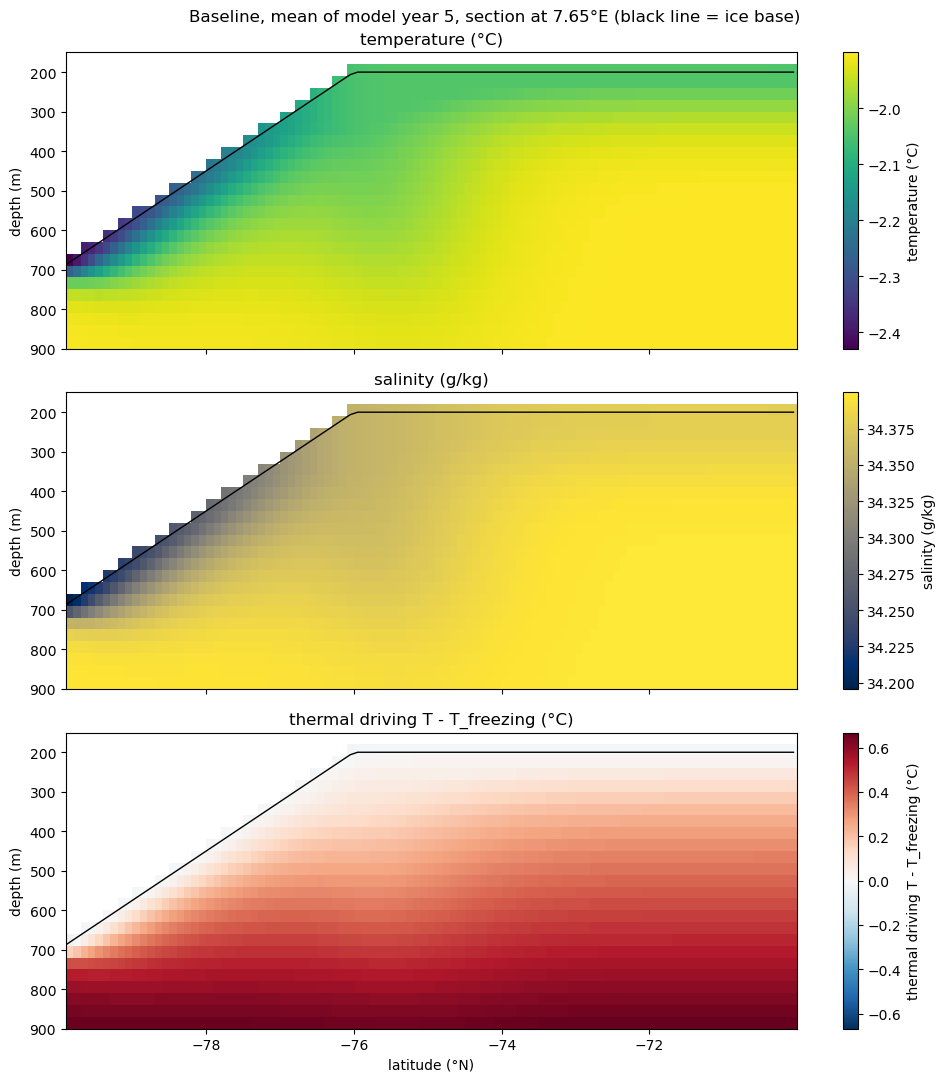

temperature     : min -2.4347, max -1.9000
salinity        : min 34.1928, max 34.4000
thermal driving : min -0.1036, max 0.6684


In [9]:
last_year = output_iterations(RUN, "state_yearly")[-1]
theta = read_field(RUN, "state_yearly", "THETA", last_year)
salt = read_field(RUN, "state_yearly", "SALT", last_year)
mask3d = grid["hfacc"] > 0
depth_c = -grid["rc"]
t_freeze = freezing_point(salt, pressure_dbar(depth_c)[:, None, None])
driving = theta - t_freeze

fig, axes = plt.subplots(3, 1, figsize=(10, 11), sharex=True)
panels = [(theta, "temperature (°C)", "viridis"), (salt, "salinity (g/kg)", "cividis"),
          (driving, "thermal driving T - T_freezing (°C)", "RdBu_r")]
for ax, (field, label, cmap) in zip(axes, panels):
    section = np.where(mask3d[:, :, i], field[:, :, i], np.nan)
    if cmap == "RdBu_r":
        lim = np.nanmax(np.abs(section))
        mesh = ax.pcolormesh(lat_edges, depth_faces, section, cmap=cmap, vmin=-lim, vmax=lim)
    else:
        mesh = ax.pcolormesh(lat_edges, depth_faces, section, cmap=cmap)
    ax.plot(lat, -grid["ice_draft"][:, i], color="k", lw=1)
    ax.set_ylim(900, 150)
    ax.set_ylabel("depth (m)")
    ax.set_title(label)
    fig.colorbar(mesh, ax=ax, label=label)
axes[-1].set_xlabel("latitude (°N)")
axes[-1].set_xlim(lat_edges[1], lat_edges[-1])
fig.suptitle(f"Baseline, mean of model year {last_year / STEPS_PER_YEAR:.0f}, section at {lon[i]:.2f}°E (black line = ice base)")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "02_ts_sections.png"), dpi=150)
plt.show()
for name, field in [("temperature", theta), ("salinity", salt), ("thermal driving", driving)]:
    print(f"{name:16s}: min {field[mask3d].min():.4f}, max {field[mask3d].max():.4f}")

## Circulation

The barotropic streamfunction shows the depth-integrated flow. I add up the eastward transport of each water column (velocity x open thickness) from the southern wall northward. Water flows along the contours, and the spacing shows the strength. I give it in milli-Sverdrups (1 mSv = 1000 m^3/s).

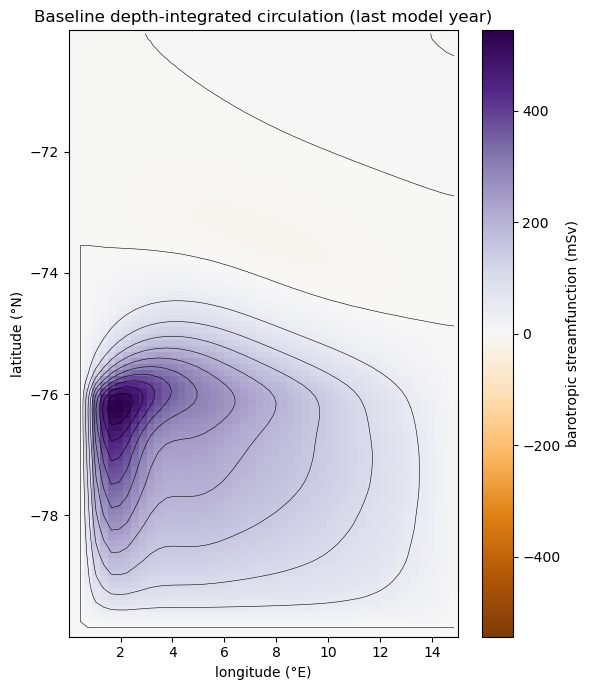

barotropic streamfunction from -9.96 to 543.81 mSv | largest speed in the yearly mean 0.0471 m/s


In [10]:
uvel = read_field(RUN, "state_yearly", "UVEL", last_year)
vvel = read_field(RUN, "state_yearly", "VVEL", last_year)
u_transport = np.sum(uvel * grid["hfacw"] * grid["drf"][:, None, None], axis=0)      # m^2/s per column
psi = np.zeros((grid["wet"].shape[0] + 1, grid["wet"].shape[1]))
for j in range(grid["wet"].shape[0]):
    psi[j + 1, :] = psi[j, :] - u_transport[j, :] * grid["dyg"][j, :]                # m^3/s
psi_msv = psi / 1e3
fig, ax = plt.subplots(figsize=(6, 7))
lim = np.max(np.abs(psi_msv))
mesh = ax.pcolormesh(lon_edges, lat_edges, psi_msv[:-1, :], cmap="PuOr", vmin=-lim, vmax=lim)
ax.contour(lon, lat, psi_msv[:-1, :], levels=12, colors="k", linewidths=0.4)
fig.colorbar(mesh, ax=ax, label="barotropic streamfunction (mSv)")
ax.set_xlabel("longitude (°E)")
ax.set_ylabel("latitude (°N)")
ax.set_title("Baseline depth-integrated circulation (last model year)")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "02_barotropic_streamfunction.png"), dpi=150)
plt.show()
print(f"barotropic streamfunction from {psi_msv.min():.2f} to {psi_msv.max():.2f} mSv | largest speed in the yearly mean "
      f"{np.max(np.sqrt(uvel ** 2 + vvel ** 2)):.4f} m/s")

The north-south overturning shows the ice pump's loop in the vertical. I add up the northward transport across each latitude, from the top down. A negative value here means water moves south (toward the deep grounding line) below that depth and north above it.

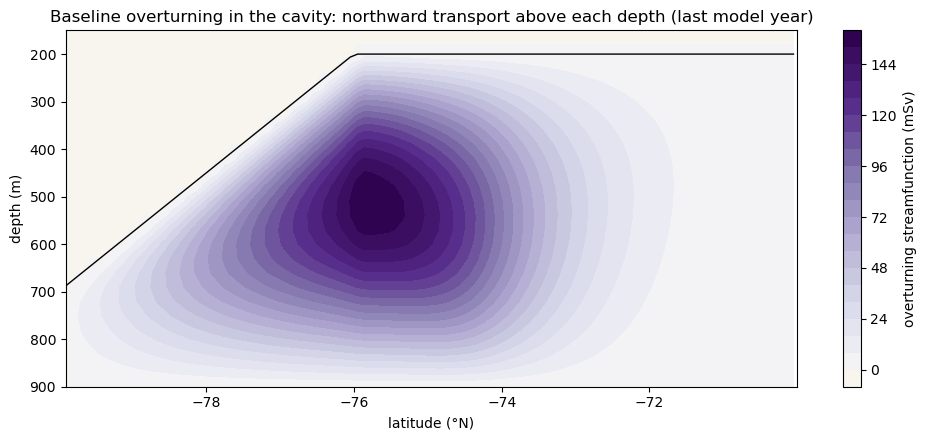

overturning streamfunction from -0.00 to 159.57 mSv


In [11]:
v_transport = np.sum(vvel * grid["hfacs"] * grid["dxg"][None, :, :], axis=2) * grid["drf"][:, None]   # m^3/s per level and row
overturning = np.zeros((len(grid["drf"]) + 1, v_transport.shape[1]))
for k in range(len(grid["drf"])):
    overturning[k + 1, :] = overturning[k, :] + v_transport[k, :]
overturning_msv = overturning / 1e3
fig, ax = plt.subplots(figsize=(10, 4.5))
lim = np.max(np.abs(overturning_msv))
mesh = ax.contourf(lat, depth_faces, overturning_msv, levels=21, cmap="PuOr", vmin=-lim, vmax=lim)
ax.plot(lat, -grid["ice_draft"][:, i], color="k", lw=1)
ax.set_ylim(900, 150)
ax.set_xlim(lat_edges[1], lat_edges[-1])
ax.set_xlabel("latitude (°N)")
ax.set_ylabel("depth (m)")
ax.set_title("Baseline overturning in the cavity: northward transport above each depth (last model year)")
fig.colorbar(mesh, ax=ax, label="overturning streamfunction (mSv)")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "02_overturning.png"), dpi=150)
plt.show()
print(f"overturning streamfunction from {overturning_msv.min():.2f} to {overturning_msv.max():.2f} mSv")